In [1]:
# Check that a Tesla T4 is connected
!nvidia-smi

# Install or upgrade Triton and PyTorch
!pip install --upgrade torch triton


import torch
from scipy.sparse import random
import numpy as np

# Import the Triton components we defined earlier
import triton
import triton.language as tl

Tue Sep 15 03:10:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:

"""
Triton translations of the CUDA.jl kernels in
AlexandreChern/IJHPCA_revision/CUDA_kernels_second_new.jl.

IMPORTANT:
- All PDE vectors/coefficient arrays are 1-D CUDA tensors containing the
  Julia column-major storage, i.e. linear index k in Julia maps to k-1 here.
- Floating point arrays should normally be torch.float32.
- Nr1/Ns1 are the Julia dimensions.
- The four face kernels are intentionally separate, matching the Julia code.
- The large `cuda_knl_2_x` Julia kernel writes neighboring output entries
  from boundary threads. Here it is represented by the race-free decomposition
  x_interior + x_f1 + x_f2 + x_f3 + x_f4.
"""

import torch
import triton
import triton.language as tl


# ---------------------------------------------------------------------------
# Utility: 2-D interior variable-coefficient operator
# ---------------------------------------------------------------------------

@triton.jit
def x_interior_kernel(
    hr, hs, x_ptr, nr1, ns1,
    crr_ptr, css_ptr, crs_ptr, out_ptr,
):
    # Julia:
    # i = global x coordinate, j = global y coordinate
    # global_index = (j-1)*Nr1 + i
    pid_i = tl.program_id(0)
    pid_j = tl.program_id(1)

    # Julia source: i runs over Ns1 (slow/column dimension), j over Nr1.
    i = pid_i + 2                 # Julia i: 2..Ns1-1
    j = pid_j + 2                 # Julia j: 2..Nr1-1

    if i <= ns1 - 1 and j <= nr1 - 1:
        g = (i - 1) * nr1 + (j - 1)  # 0-based flat offset

        crr_m = tl.load(crr_ptr + g - 1)
        crr_0 = tl.load(crr_ptr + g)
        crr_p = tl.load(crr_ptr + g + 1)

        css_m = tl.load(css_ptr + g - nr1)
        css_0 = tl.load(css_ptr + g)
        css_p = tl.load(css_ptr + g + nr1)

        crs_m = tl.load(crs_ptr + g - 1)
        crs_p = tl.load(crs_ptr + g + 1)
        crs_d = tl.load(crs_ptr + g - nr1)
        crs_u = tl.load(crs_ptr + g + nr1)

        xm = tl.load(x_ptr + g - 1)
        x0 = tl.load(x_ptr + g)
        xp = tl.load(x_ptr + g + 1)
        xd = tl.load(x_ptr + g - nr1)
        xu = tl.load(x_ptr + g + nr1)

        xdm = tl.load(x_ptr + g - nr1 - 1)
        xdp = tl.load(x_ptr + g - nr1 + 1)
        xum = tl.load(x_ptr + g + nr1 - 1)
        xup = tl.load(x_ptr + g + nr1 + 1)

        arr = (
            (-0.5 * crr_m - 0.5 * crr_0) * xm
            + (0.5 * crr_m + crr_0 + 0.5 * crr_p) * x0
            + (-0.5 * crr_0 - 0.5 * crr_p) * xp
        )

        ass = (
            (-0.5 * css_m - 0.5 * css_0) * xd
            + (0.5 * css_m + css_0 + 0.5 * css_p) * x0
            + (-0.5 * css_0 - 0.5 * css_p) * xu
        )

        ars = (
            0.5 * crs_m * (-0.5 * xdm + 0.5 * xum)
            - 0.5 * crs_p * (-0.5 * xdp + 0.5 * xup)
        )

        asr = (
            0.5 * crs_d * (-0.5 * xdm + 0.5 * xdp)
            - 0.5 * crs_u * (-0.5 * xum + 0.5 * xup)
        )

        y = hs * (1.0 / hr) * (arr + ass + ars + asr)
        tl.store(out_ptr + g, y)


# ---------------------------------------------------------------------------
# Face 1: left boundary (Julia cuda_knl_2_x_f1)
# ---------------------------------------------------------------------------

@triton.jit
def x_f1_kernel(
    hr, hs, x_ptr, nr1, ns1,
    crr_ptr, css_ptr, crs_ptr, psi1_ptr, psi2_ptr,
    out_ptr,
):
    i0 = tl.program_id(0) + 1  # Julia i = 1..Ns1

    if i0 <= ns1:
        g = (i0 - 1) * nr1       # j=1 in Julia, 0-based

        if i0 >= 2 and i0 <= ns1 - 1:
            crr0 = tl.load(crr_ptr + g)
            crr1 = tl.load(crr_ptr + g + 1)

            cssm = tl.load(css_ptr + g - nr1)
            css0 = tl.load(css_ptr + g)
            cssp = tl.load(css_ptr + g + nr1)

            crs0 = tl.load(crs_ptr + g)
            crs1 = tl.load(crs_ptr + g + 1)
            crsd = tl.load(crs_ptr + g - nr1)
            crsu = tl.load(crs_ptr + g + nr1)

            x0 = tl.load(x_ptr + g)
            x1 = tl.load(x_ptr + g + 1)
            xd = tl.load(x_ptr + g - nr1)
            xu = tl.load(x_ptr + g + nr1)
            xu1 = tl.load(x_ptr + g + nr1 + 1)

            x2 = tl.load(x_ptr + g + 2 * 0 + 2)

            arr = (0.5 * crr0 + 0.5 * crr1) * x0 + (-0.5 * crr0 - 0.5 * crr1) * x1
            ass = (
                (-0.5 * cssm - 0.5 * css0) * xd
                + (0.5 * cssm + css0 + 0.5 * cssp) * x0
                + (-0.5 * css0 - 0.5 * cssp) * xu
            )
            ars = (
                -0.5 * crs0 * (-0.5 * xd + 0.5 * xu)
                -0.5 * crs1 * (-0.5 * xu1 + 0.5 * tl.load(x_ptr + g + 1 - nr1))
            )
            asr = (
                0.5 * crsd * (-0.5 * xd + 0.5 * x1)
                -0.5 * crsu * (-0.5 * xu + 0.5 * xu1)
            )

            mod = (
                -hs * (1.0 / hr) * crr0 * (1.5 * x0 - 2.0 * x1 + 0.5 * x2)
                + crs0 * (-0.5 * xd + 0.5 * xu)
                + crr0 * (4.0 + crr0 / tl.load(psi1_ptr + i0 - 1)) * x0
                - hs * crr0 * ((1.0 / hr) * 1.5 * x0)
                + 0.5 * crsd * xd
                - 0.5 * crsu * xu
            )

            y = hs * (1.0 / hr) * (arr + ass * 0.5 * (hr / hs) * (hs / hr) + ars + asr) + mod
            # The expression above deliberately keeps the Julia factors explicit.
            # Reconstruct exact Julia scaling for the first three terms:
            y = (
                hs * (1.0 / hr) * arr
                + hr * 0.5 * (1.0 / hs) * ass
                + ars + asr + mod
            )
            tl.store(out_ptr + g, y)

            # The Julia f1 kernel also writes the two neighboring entries.
            tl.store(
                out_ptr + g + 1,
                -hs * (crr0 * (1.0 / hr) * (-2.0) * x0)
            )
            tl.store(
                out_ptr + g + 2,
                -hs * (crr0 * (1.0 / hr) * 0.5 * x0)
            )

        # Julia special corner i==1
        if i0 == 1:
            crr0 = tl.load(crr_ptr + g)
            crr1 = tl.load(crr_ptr + g + 1)
            crs0 = tl.load(crs_ptr + g)
            crs1 = tl.load(crs_ptr + g + 1)
            crsu = tl.load(crs_ptr + g + nr1)
            css0 = tl.load(css_ptr + g)
            cssu = tl.load(css_ptr + g + nr1)

            x0 = tl.load(x_ptr + g)
            x1 = tl.load(x_ptr + g + 1)
            xu = tl.load(x_ptr + g + nr1)
            xu1 = tl.load(x_ptr + g + nr1 + 1)
            x2 = tl.load(x_ptr + g + 2)

            y = (
                hs * 0.5 * (1.0 / hr) *
                ((0.5 * crr0 + 0.5 * crr1) * x0
                 + (-0.5 * crr0 - 0.5 * crr1) * x1)
                + (-0.5 * crs0 * (-0.5 * x0 + 0.5 * xu)
                   - 0.5 * crs1 * (-0.5 * x1 + 0.5 * xu1))
                - hs * 0.5 * (1.0 / hr) * crr0 * (1.5 * x0 - 2.0 * x1 + 0.5 * x2)
                + 0.5 * crs0 * (-x0 + xu)
                + 0.5 * crr0 * (4.0 + crr0 / tl.load(psi1_ptr)) * x0
                - hs * 0.5 * crr0 * ((1.0 / hr) * 1.5 * x0)
                - 0.5 * crsu * xu
                - 0.5 * crs0 * x0
                + hr * 0.5 * (1.0 / hs) *
                  ((0.5 * css0 + 0.5 * cssu) * x0
                   + (-0.5 * css0 - 0.5 * cssu) * xu)
                - 0.5 * (crs0 * (-0.5 * x0 + 0.5 * x1)
                          + crsu * (-0.5 * xu + 0.5 * xu1))
            )
            tl.store(out_ptr + g, y)
            tl.store(out_ptr + g + 1, -hs * 0.5 * crr0 * (1.0 / hr) * (-2.0) * x0)
            tl.store(out_ptr + g + 2, -hs * 0.5 * crr0 * (1.0 / hr) * 0.5 * x0)

        # Julia special corner i==Ns1
        if i0 == ns1:
            g = (ns1 - 1) * nr1
            crr0 = tl.load(crr_ptr + g)
            crr1 = tl.load(crr_ptr + g + 1)
            crs0 = tl.load(crs_ptr + g)
            crs1 = tl.load(crs_ptr + g + 1)
            crsd = tl.load(crs_ptr + g - nr1)
            cssd = tl.load(css_ptr + g - nr1)
            css0 = tl.load(css_ptr + g)

            x0 = tl.load(x_ptr + g)
            x1 = tl.load(x_ptr + g + 1)
            xd = tl.load(x_ptr + g - nr1)
            xd1 = tl.load(x_ptr + g - nr1 + 1)
            x2 = tl.load(x_ptr + g + 2)

            y = (
                hs * 0.5 * (1.0 / hr) *
                ((0.5 * crr0 + 0.5 * crr1) * x0
                 + (-0.5 * crr0 - 0.5 * crr1) * x1)
                + (-0.5 * crs0 * (-0.5 * xd + 0.5 * x0)
                   - 0.5 * crs1 * (-0.5 * xd1 + 0.5 * x1))
                - hs * 0.5 * (1.0 / hr) * crr0 * (1.5 * x0 - 2.0 * x1 + 0.5 * x2)
                + 0.5 * crs0 * (-xd + x0)
                + 0.5 * crr0 * (4.0 + crr0 / tl.load(psi1_ptr + ns1 - 1)) * x0
                - hs * 0.5 * crr0 * ((1.0 / hr) * 1.5 * x0)
                + 0.5 * crsd * xd
                + 0.5 * crs0 * x0
                + hr * 0.5 * (1.0 / hs) *
                  ((-0.5 * cssd - 0.5 * css0) * xd
                   + (0.5 * cssd + 0.5 * css0) * x0)
            )
            tl.store(out_ptr + g, y)
            tl.store(out_ptr + g + 1, -hs * 0.5 * crr0 * (1.0 / hr) * (-2.0) * x0)
            tl.store(out_ptr + g + 2, -hs * 0.5 * crr0 * (1.0 / hr) * 0.5 * x0)


# ---------------------------------------------------------------------------
# Face 2 (right), face 3 (bottom), face 4 (top)
#
# These use the same mathematical expressions as the Julia source, with
# one Triton program per face coordinate.
# ---------------------------------------------------------------------------

@triton.jit
def x_f2_kernel(
    hr, hs, x_ptr, nr1, ns1,
    crr_ptr, css_ptr, crs_ptr, psi1_ptr, psi2_ptr,
    out_ptr,
):
    j = tl.program_id(0) + 1
    if j <= ns1:
        g = j * nr1 - 1
        if j >= 2 and j <= ns1 - 1:
            crrm = tl.load(crr_ptr + g - 1)
            crr0 = tl.load(crr_ptr + g)
            cssm = tl.load(css_ptr + g - nr1)
            css0 = tl.load(css_ptr + g)
            cssp = tl.load(css_ptr + g + nr1)
            crsm = tl.load(crs_ptr + g - 1)
            crs0 = tl.load(crs_ptr + g)
            crsd = tl.load(crs_ptr + g - nr1)
            crsu = tl.load(crs_ptr + g + nr1)
            x_m = tl.load(x_ptr + g - 1)
            x0 = tl.load(x_ptr + g)
            x_d = tl.load(x_ptr + g - nr1)
            x_u = tl.load(x_ptr + g + nr1)
            x_dm = tl.load(x_ptr + g - nr1 - 1)
            x_um = tl.load(x_ptr + g + nr1 - 1)
            y = (
                hs * (1.0 / hr) * ((-0.5*crrm-0.5*crr0)*x_m + (0.5*crrm+0.5*crr0)*x0)
                + hr * 0.5 * (1.0 / hs) *
                  ((-0.5*cssm-0.5*css0)*x_d
                   + (0.5*cssm+css0+0.5*cssp)*x0
                   + (-0.5*css0-0.5*cssp)*x_u)
                + 0.5*crsm*(-0.5*x_dm+0.5*x_um)
                + 0.5*crs0*(-0.5*x_d+0.5*x_u)
                - hs*(1.0/hr)*crr0*(1.5*x0-2.0*x_m+0.5*tl.load(x_ptr+g-2))
                - crs0*(-0.5*tl.load(x_ptr+g-nr1)+0.5*tl.load(x_ptr+g+nr1))
                + crr0*(4.0+crr0/tl.load(psi2_ptr+j-1))*x0
                - hs*crr0*((1.0/hr)*1.5*x0)
                - 0.5*crsd* x_d + 0.5*crsu*x_u
            )
            tl.store(out_ptr+g, y)
            tl.store(out_ptr+g-1, -hs*crr0*(1.0/hr)*(-2.0)*x0)
            tl.store(out_ptr+g-2, -hs*crr0*(1.0/hr)*0.5*x0)

        if j == 1:
            g = nr1 - 1
            # exact right/bottom corner from f2
            crra = tl.load(crr_ptr+g-1); crr0 = tl.load(crr_ptr+g)
            crsa = tl.load(crs_ptr+g-1); crs0 = tl.load(crs_ptr+g)
            crsd = tl.load(crs_ptr+g-nr1); crsu = tl.load(crs_ptr+g+nr1)
            cssd = tl.load(css_ptr+g-nr1); css0 = tl.load(css_ptr+g)
            x0 = tl.load(x_ptr+g); xm = tl.load(x_ptr+g-1)
            xd = tl.load(x_ptr+g-nr1); xd_m = tl.load(x_ptr+g-nr1-1)
            x2m = tl.load(x_ptr+g-2)
            y = (
                hs*0.5*(1.0/hr)*((-0.5*crra-0.5*crr0)*xm+(0.5*crra+0.5*crr0)*x0)
                + 0.5*crsa*(-0.5*xm+0.5*x0)
                + 0.5*crs0*(-0.5*xd+0.5*x0)
                - hs*0.5*(1.0/hr)*crr0*(1.5*x0-2*xm+0.5*x2m)
                - 0.5*crs0*(-xd+x0)
                + 0.5*crr0*(4.0+crr0/tl.load(psi2_ptr))*x0
                - hs*0.5*crr0*((1.0/hr)*1.5*x0)
                + 0.5*crsu*xd
                + 0.5*crs0*x0
            )
            tl.store(out_ptr+g, y)
            tl.store(out_ptr+g-1, -hs*0.5*crr0*(1.0/hr)*(-2)*x0)
            tl.store(out_ptr+g-2, -hs*0.5*crr0*(1.0/hr)*0.5*x0)

        if j == ns1:
            g = ns1*nr1 - 1
            crrm=tl.load(crr_ptr+g-1); crr0=tl.load(crr_ptr+g)
            crsm=tl.load(crs_ptr+g-1); crs0=tl.load(crs_ptr+g)
            crsd=tl.load(crs_ptr+g-nr1)
            cssd=tl.load(css_ptr+g-nr1); css0=tl.load(css_ptr+g)
            x0=tl.load(x_ptr+g); xm=tl.load(x_ptr+g-1)
            xd=tl.load(x_ptr+g-nr1); xdm=tl.load(x_ptr+g-nr1-1)
            x2m=tl.load(x_ptr+g-2)
            y=(
                hs*0.5*(1.0/hr)*((-0.5*crrm-0.5*crr0)*xm+(0.5*crrm+0.5*crr0)*x0)
                + 0.5*crsm*(-0.5*xdm+0.5*xm)
                + 0.5*crs0*(-0.5*xd+0.5*x0)
                - hs*0.5*(1.0/hr)*crr0*(1.5*x0-2*xm+0.5*x2m)
                - 0.5*crs0*(-xd+x0)
                + 0.5*crr0*(4.0+crr0/tl.load(psi2_ptr+ns1-1))*x0
                - hs*0.5*crr0*((1.0/hr)*1.5*x0)
                - 0.5*crsd*xd
                - 0.5*crs0*x0
                + hr*0.5*(1.0/hs)*((-0.5*cssd-0.5*css0)*xd+(0.5*cssd+0.5*css0)*x0)
            )
            tl.store(out_ptr+g,y)
            tl.store(out_ptr+g-1,-hs*0.5*crr0*(1.0/hr)*(-2)*x0)
            tl.store(out_ptr+g-2,-hs*0.5*crr0*(1.0/hr)*0.5*x0)


@triton.jit
def x_f3_kernel(hr, hs, x_ptr, nr1, ns1, crr_ptr, css_ptr, crs_ptr,
                psi1_ptr, psi2_ptr, out_ptr):
    i = tl.program_id(0) + 1
    if i <= nr1:
        g = i - 1
        if i >= 2 and i <= nr1 - 1:
            cm=tl.load(crr_ptr+g-1); c0=tl.load(crr_ptr+g); cp=tl.load(crr_ptr+g+1)
            s0=tl.load(css_ptr+g); su=tl.load(css_ptr+g+nr1)
            rm=tl.load(crs_ptr+g-1); rp=tl.load(crs_ptr+g+1); r0=tl.load(crs_ptr+g); ru=tl.load(crs_ptr+g+nr1)
            xm=tl.load(x_ptr+g-1); x0=tl.load(x_ptr+g); xp=tl.load(x_ptr+g+1)
            xu=tl.load(x_ptr+g+nr1); xum=tl.load(x_ptr+g+nr1-1); xup=tl.load(x_ptr+g+nr1+1)
            y=(
                hs*0.5*(1/hr)*((-0.5*cm-0.5*c0)*xm+(0.5*cm+c0+0.5*cp)*x0+(-0.5*c0-0.5*cp)*xp)
                + hr*(1/hs)*((0.5*s0+0.5*su)*x0+(-0.5*s0-0.5*su)*xu)
                + 0.5*rm*(-0.5*xm+0.5*xum)
                -0.5*rp*(-0.5*xp+0.5*xup)
                -0.5*r0*(-0.5*xm+0.5*xp)
                -0.5*ru*(-0.5*xum+0.5*xup)
            )
            tl.store(out_ptr+g,y)
        if i == 1:
            s0=tl.load(css_ptr+g); su=tl.load(css_ptr+g+nr1)
            r0=tl.load(crs_ptr+g); ru=tl.load(crs_ptr+g+nr1)
            x0=tl.load(x_ptr+g); x1=tl.load(x_ptr+g+1); xu=tl.load(x_ptr+g+nr1); xu1=tl.load(x_ptr+g+nr1+1)
            y=hr*0.5*(1/hs)*((0.5*s0+0.5*su)*x0+(-0.5*s0-0.5*su)*xu) \
              -0.5*(r0*(-0.5*x0+0.5*x1)+ru*(-0.5*xu+0.5*xu1))
            tl.store(out_ptr+g,y)
        if i == nr1:
            s0=tl.load(css_ptr+g); su=tl.load(css_ptr+g+nr1)
            r0=tl.load(crs_ptr+g); rm=tl.load(crs_ptr+g-1); ru=tl.load(crs_ptr+g+nr1)
            x0=tl.load(x_ptr+g); xm=tl.load(x_ptr+g-1); xu=tl.load(x_ptr+g+nr1); xum=tl.load(x_ptr+g+nr1-1)
            y=hr*0.5*(1/hs)*((0.5*s0+0.5*su)*x0+(-0.5*s0-0.5*su)*xu) \
              -0.5*(r0*(-0.5*xm+0.5*x0)+ru*(-0.5*xum+0.5*xu))
            tl.store(out_ptr+g,y)


@triton.jit
def x_f4_kernel(hr, hs, x_ptr, nr1, ns1, crr_ptr, css_ptr, crs_ptr,
                psi1_ptr, psi2_ptr, out_ptr):
    i = tl.program_id(0) + 1
    if i <= nr1:
        g = (ns1-1)*nr1 + i - 1
        if i >= 2 and i <= nr1 - 1:
            cm=tl.load(crr_ptr+g-1); c0=tl.load(crr_ptr+g); cp=tl.load(crr_ptr+g+1)
            sm=tl.load(css_ptr+g-nr1); s0=tl.load(css_ptr+g)
            rm=tl.load(crs_ptr+g-1); rp=tl.load(crs_ptr+g+1); rd=tl.load(crs_ptr+g-nr1); r0=tl.load(crs_ptr+g)
            xm=tl.load(x_ptr+g-1); x0=tl.load(x_ptr+g); xp=tl.load(x_ptr+g+1)
            xd=tl.load(x_ptr+g-nr1); xdm=tl.load(x_ptr+g-nr1-1); xdp=tl.load(x_ptr+g-nr1+1)
            y=(
                hs*0.5*(1/hr)*((-0.5*cm-0.5*c0)*xm+(0.5*cm+c0+0.5*cp)*x0+(-0.5*c0-0.5*cp)*xp)
                + hr*(1/hs)*((-0.5*sm-0.5*s0)*xd+(0.5*sm+0.5*s0)*x0)
                + 0.5*rm*(-0.5*xdm+0.5*xm)
                -0.5*rp*(-0.5*xdp+0.5*xp)
                +0.5*rd*(-0.5*xm+0.5*xp)
                +0.5*r0*(-0.5*xm+0.5*xp)
            )
            tl.store(out_ptr+g,y)
        if i == 1:
            sm=tl.load(css_ptr+g-nr1); s0=tl.load(css_ptr+g)
            rd=tl.load(crs_ptr+g-nr1); r0=tl.load(crs_ptr+g)
            x0=tl.load(x_ptr+g); xp=tl.load(x_ptr+g+1); xd=tl.load(x_ptr+g-nr1); xdp=tl.load(x_ptr+g+1-nr1)
            y=hr*0.5*(1/hs)*((-0.5*sm-0.5*s0)*xd+(0.5*sm+0.5*s0)*x0) \
              +0.5*(rd*(-0.5*xd+0.5*xdp)+r0*(-0.5*x0+0.5*xp))
            tl.store(out_ptr+g,y)
        if i == nr1:
            sm=tl.load(css_ptr+g-nr1); s0=tl.load(css_ptr+g)
            rd=tl.load(crs_ptr+g-nr1); r0=tl.load(crs_ptr+g)
            x0=tl.load(x_ptr+g); xm=tl.load(x_ptr+g-1); xd=tl.load(x_ptr+g-nr1)
            xdm=tl.load(x_ptr+g-1-nr1)
            y=hr*0.5*(1/hs)*((-0.5*sm-0.5*s0)*xd+(0.5*sm+0.5*s0)*x0) \
              +0.5*(rd*(-0.5*xdm+0.5*xd)+r0*(-0.5*xm+0.5*x0))
            tl.store(out_ptr+g,y)


# ---------------------------------------------------------------------------
# H and H^{-1}
# ---------------------------------------------------------------------------

@triton.jit
def H_kernel(hr, hs, x_ptr, nr1, ns1, out_ptr, inverse: tl.constexpr):
    pid_x = tl.program_id(0)
    pid_y = tl.program_id(1)
    i = pid_x + 1
    j = pid_y + 1
    if i <= ns1 and j <= nr1:
        g = (i - 1) * nr1 + (j - 1)
        boundary_x = (i == 1) | (i == ns1)
        boundary_y = (j == 1) | (j == nr1)
        corner = boundary_x & boundary_y
        edge = boundary_x | boundary_y
        val = tl.load(x_ptr + g)
        if inverse:
            scale = 1.0 / (hr * hs)
            out = tl.where(corner, 4.0 * scale * val,
                  tl.where(edge, 2.0 * scale * val, scale * val))
        else:
            scale = hr * hs
            out = tl.where(corner, 0.25 * scale * val,
                  tl.where(edge, 0.5 * scale * val, scale * val))
        tl.store(out_ptr + g, out)


# ---------------------------------------------------------------------------
# Prolongation / restriction
# ---------------------------------------------------------------------------

@triton.jit
def prolongation_2d_kernel(idata_ptr, odata_ptr, nx, ny):
    pid_x = tl.program_id(0)
    pid_y = tl.program_id(1)
    i = pid_x + 1
    j = pid_y + 1

    # Julia source uses 1-based column-major indexing.
    if i <= nx - 1 and j <= ny - 1:
        g = (i - 1) * nx + (j - 1)
        o_stride = 2 * nx - 1
        o00 = (2*i - 2) * (2*nx - 1) + (2*j - 2)
        o01 = o00 + 1
        o10 = o00 + (2*ny - 1)
        o11 = o10 + 1

        a = tl.load(idata_ptr + g)
        b = tl.load(idata_ptr + g + 1)
        c = tl.load(idata_ptr + ny)
        d = tl.load(idata_ptr + ny + 1)

        tl.store(odata_ptr + o00, a)
        tl.store(odata_ptr + o01, 0.5*(a+b))
        tl.store(odata_ptr + o10, 0.5*(a+c))
        tl.store(odata_ptr + o11, 0.25*(a+c+b+d))

    if j <= ny - 1 and i == nx:
        g = (i - 1) * nx + (j - 1)
        o_stride = 2 * nx - 1
        o00 = (2*i - 2) * o_stride + (2*j - 2)
        a = tl.load(idata_ptr + g)
        b = tl.load(idata_ptr + g + 1)
        tl.store(odata_ptr + o00, a)
        tl.store(odata_ptr + o00 + 1, 0.5*(a+b))

    if i <= nx - 1 and j == ny:
        g = (i - 1) * nx + (j - 1)
        o_stride = 2 * nx - 1
        o00 = (2*i - 2) * o_stride + (2*j - 2)
        a = tl.load(idata_ptr + g)
        c = tl.load(idata_ptr + ny)
        tl.store(odata_ptr + o00, a)
        tl.store(odata_ptr + o00 + o_stride, 0.5*(a+c))

    if i == nx and j == ny:
        g = (i - 1) * nx + (j - 1)
        o_stride = 2 * nx - 1
        o00 = (2*i - 2) * o_stride + (2*j - 2)
        tl.store(odata_ptr + o00, tl.load(idata_ptr + g))


@triton.jit
def restriction_2d_kernel(idata_ptr, odata_ptr, nx, ny):
    # This follows the exact indexing formulas in the Julia restriction kernel.
    pid_x = tl.program_id(0)
    pid_y = tl.program_id(1)
    i = pid_x + 1
    j = pid_y + 1

    nox = (nx + 1) // 2
    noy = (ny + 1) // 2

    if i <= nox and j <= noy:
        # Interior
        if i >= 2 and i <= nox-1 and j >= 2 and j <= noy-1:
            a = (2*i - 2) * nx + (2*j - 2)
            v = (
                4.0 * tl.load(idata_ptr + a)
                + 2.0 * (
                    tl.load(idata_ptr + a + nx)
                    + tl.load(idata_ptr + a - nx)
                    + tl.load(idata_ptr + a + 1)
                    + tl.load(idata_ptr + a - 1)
                )
                + tl.load(idata_ptr + a - nx - 1)
                + tl.load(idata_ptr + a + nx + 1)
                + tl.load(idata_ptr + a - nx + 1)
                + tl.load(idata_ptr + a + nx - 1)
            ) / 16.0
            tl.store(odata_ptr + (i-1)*noy + (j-1), v)

        # Four corners
        if i == 1 and j == 1:
            v = (tl.load(idata_ptr) + tl.load(idata_ptr+nx)
                 + tl.load(idata_ptr+1) + tl.load(idata_ptr+nx+1)) / 4.0
            tl.store(odata_ptr, v)

        if i == nox and j == 1:
            a = (2*i-2)*ny
            v = (tl.load(idata_ptr+a) + tl.load(idata_ptr+a-nx)
                 + tl.load(idata_ptr+a+1) + tl.load(idata_ptr+a-nx+1)) / 4.0
            tl.store(odata_ptr + (i-1)*noy, v)

        if i == 1 and j == noy:
            a = 2*j-2
            v = (tl.load(idata_ptr+a) + tl.load(idata_ptr+a+nx)
                 + tl.load(idata_ptr+a-1) + tl.load(idata_ptr+a+nx-1)) / 4.0
            tl.store(odata_ptr + (j-1), v)

        if i == nox and j == noy:
            a = (2*i-2)*ny + (2*j-2)
            v = (tl.load(idata_ptr+a) + tl.load(idata_ptr+a-nx)
                 + tl.load(idata_ptr+a-1) + tl.load(idata_ptr+a-nx-1)) / 4.0
            tl.store(odata_ptr + (i-1)*noy + (j-1), v)

        # Bottom/top edges
        if i >= 2 and i <= nox-1 and j == 1:
            a = (2*i-2)*ny
            v = (
                2*tl.load(idata_ptr+a)
                + tl.load(idata_ptr+a-nx)
                + tl.load(idata_ptr+a+nx)
                + 2*tl.load(idata_ptr+a+1)
                + tl.load(idata_ptr+a-nx+1)
                + tl.load(idata_ptr+a+nx+1)
            ) / 8.0
            tl.store(odata_ptr+(i-1)*noy, v)

        if i >= 2 and i <= nox-1 and j == noy:
            a = (2*i-2)*ny + (2*j-2)
            v = (
                2*tl.load(idata_ptr+a)
                + tl.load(idata_ptr+a-nx)
                + tl.load(idata_ptr+a+nx)
                + 2*tl.load(idata_ptr+a-1)
                + tl.load(idata_ptr+a-nx-1)
                + tl.load(idata_ptr+a+nx-1)
            ) / 8.0
            tl.store(odata_ptr+(i-1)*noy+(j-1), v)

        # Left/right edges
        if i == 1 and j >= 2 and j <= noy-1:
            a = 2*j-2
            v = (
                2*tl.load(idata_ptr+a)
                + tl.load(idata_ptr+a-1)
                + tl.load(idata_ptr+a+1)
                + 2*tl.load(idata_ptr+a+nx)
                + tl.load(idata_ptr+a+nx-1)
                + tl.load(idata_ptr+a+nx+1)
            ) / 8.0
            tl.store(odata_ptr+(j-1), v)

        if i == nox and j >= 2 and j <= noy-1:
            a = (2*i-2)*ny + (2*j-2)
            v = (
                2*tl.load(idata_ptr+a)
                + tl.load(idata_ptr+a-1)
                + tl.load(idata_ptr+a+1)
                + 2*tl.load(idata_ptr+a-nx)
                + tl.load(idata_ptr+a-nx-1)
                + tl.load(idata_ptr+a-nx+1)
            ) / 8.0
            tl.store(odata_ptr+(i-1)*noy+(j-1), v)


# ---------------------------------------------------------------------------
# Python launch wrappers
# ---------------------------------------------------------------------------

def launch_x_interior(hr, hs, x, Nr1, Ns1, crr, css, crs, out):
    grid = (max(Ns1-2, 0), max(Nr1-2, 0))
    x_interior_kernel[grid](hr, hs, x, Nr1, Ns1, crr, css, crs, out)
    return out


def launch_x_f1(hr, hs, x, Nr1, Ns1, crr, css, crs, psi1, psi2, out):
    x_f1_kernel[(Ns1,)](hr, hs, x, Nr1, Ns1, crr, css, crs, psi1, psi2, out)
    return out


def launch_x_f2(hr, hs, x, Nr1, Ns1, crr, css, crs, psi1, psi2, out):
    x_f2_kernel[(Ns1,)](hr, hs, x, Nr1, Ns1, crr, css, crs, psi1, psi2, out)
    return out


def launch_x_f3(hr, hs, x, Nr1, Ns1, crr, css, crs, psi1, psi2, out):
    x_f3_kernel[(Nr1,)](hr, hs, x, Nr1, Ns1, crr, css, crs, psi1, psi2, out)
    return out


def launch_x_f4(hr, hs, x, Nr1, Ns1, crr, css, crs, psi1, psi2, out):
    x_f4_kernel[(Nr1,)](hr, hs, x, Nr1, Ns1, crr, css, crs, psi1, psi2, out)
    return out


def launch_H(hr, hs, x, Nr1, Ns1, out):
    H_kernel[(Ns1, Nr1)](hr, hs, x, Nr1, Ns1, out, inverse=False)
    return out


def launch_H_inverse(hr, hs, x, Nr1, Ns1, out):
    H_kernel[(Ns1, Nr1)](hr, hs, x, Nr1, Ns1, out, inverse=True)
    return out


def launch_prolongation(x, out, Nx, Ny):
    grid = ((Nx + 15)//16, (Ny + 15)//16)
    prolongation_2d_kernel[grid](x, out, Nx, Ny)
    return out


def launch_restriction(x, out, Nx, Ny):
    nox = (Nx + 1)//2
    noy = (Ny + 1)//2
    grid = ((nox + 15)//16, (noy + 15)//16)
    restriction_2d_kernel[grid](x, out, Nx, Ny)
    return out


# ---------------------------------------------------------------------------
# Smoke test
# ---------------------------------------------------------------------------

def smoke_test():
    assert torch.cuda.is_available(), "CUDA GPU is required"

    device = "cuda"
    Nr1, Ns1 = 64, 48
    n = Nr1 * Ns1

    hr = 0.1
    hs = 0.2

    x = torch.randn(n, device=device, dtype=torch.float32)
    crr = torch.rand(n, device=device, dtype=torch.float32) + 1.0
    css = torch.rand(n, device=device, dtype=torch.float32) + 1.0
    crs = torch.rand(n, device=device, dtype=torch.float32) * 0.1
    psi1 = torch.rand(Ns1, device=device, dtype=torch.float32) + 1.0
    psi2 = torch.rand(Ns1, device=device, dtype=torch.float32) + 1.0

    out = torch.empty_like(x)

    launch_x_interior(hr, hs, x, Nr1, Ns1, crr, css, crs, out)
    launch_x_f1(hr, hs, x, Nr1, Ns1, crr, css, crs, psi1, psi2, out)
    launch_x_f2(hr, hs, x, Nr1, Ns1, crr, css, crs, psi1, psi2, out)
    launch_x_f3(hr, hs, x, Nr1, Ns1, crr, css, crs, psi1, psi2, out)
    launch_x_f4(hr, hs, x, Nr1, Ns1, crr, css, crs, psi1, psi2, out)

    h_out = torch.empty_like(x)
    launch_H(hr, hs, x, Nr1, Ns1, h_out)
    launch_H_inverse(hr, hs, x, Nr1, Ns1, h_out)

    # For transfer kernels use dimensions for which the formulas are valid.
    nx, ny = 17, 17
    fine_x = 2*nx - 1
    fine_y = 2*ny - 1
    coarse = torch.randn(nx*ny, device=device)
    fine = torch.empty(fine_x*fine_y, device=device)
    launch_prolongation(coarse, fine, nx, ny)

    restricted = torch.empty(((fine_x+1)//2)*((fine_y+1)//2),
                              device=device)
    launch_restriction(fine, restricted, fine_x, fine_y)

    torch.cuda.synchronize()
    print("Triton smoke test completed.")


if __name__ == "__main__":
    smoke_test()


Triton smoke test completed.


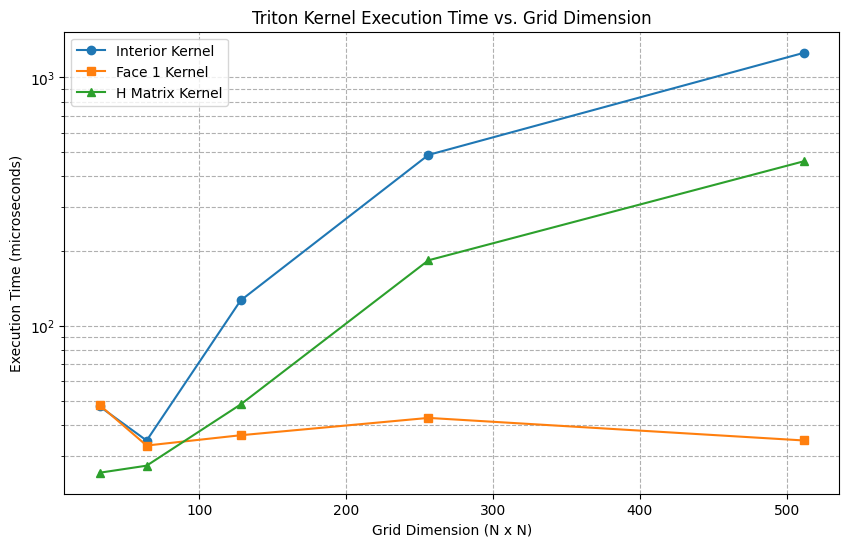

In [6]:
import time
import matplotlib.pyplot as plt

def benchmark_kernel(kernel_func, *args, repeats=100):
    # Warmup
    for _ in range(10):
        kernel_func(*args)
    torch.cuda.synchronize()

    start_time = time.perf_counter()
    for _ in range(repeats):
        kernel_func(*args)
    torch.cuda.synchronize()
    end_time = time.perf_counter()

    return (end_time - start_time) / repeats * 1e6  # Time in microseconds

def run_benchmarks():
    sizes = [32, 64, 128, 256, 512]
    interior_times = []
    f1_times = []
    h_times = []

    device = "cuda"

    for N in sizes:
        Nr1, Ns1 = N, N
        n = Nr1 * Ns1
        hr, hs = 0.1, 0.2

        x = torch.randn(n, device=device, dtype=torch.float32)
        crr = torch.rand(n, device=device, dtype=torch.float32) + 1.0
        css = torch.rand(n, device=device, dtype=torch.float32) + 1.0
        crs = torch.rand(n, device=device, dtype=torch.float32) * 0.1
        psi1 = torch.rand(Ns1, device=device, dtype=torch.float32) + 1.0
        psi2 = torch.rand(Ns1, device=device, dtype=torch.float32) + 1.0
        out = torch.empty_like(x)

        t_int = benchmark_kernel(launch_x_interior, hr, hs, x, Nr1, Ns1, crr, css, crs, out)
        t_f1 = benchmark_kernel(launch_x_f1, hr, hs, x, Nr1, Ns1, crr, css, crs, psi1, psi2, out)
        t_h = benchmark_kernel(launch_H, hr, hs, x, Nr1, Ns1, out)

        interior_times.append(t_int)
        f1_times.append(t_f1)
        h_times.append(t_h)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, interior_times, marker='o', label='Interior Kernel')
    plt.plot(sizes, f1_times, marker='s', label='Face 1 Kernel')
    plt.plot(sizes, h_times, marker='^', label='H Matrix Kernel')

    plt.title('Triton Kernel Execution Time vs. Grid Dimension')
    plt.xlabel('Grid Dimension (N x N)')
    plt.ylabel('Execution Time (microseconds)')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.show()

run_benchmarks()

In [7]:
!jupyter nbconvert --to markdown Triton_SBP_SAT.ipynb

[NbConvertApp] WARNING | pattern 'Triton_SBP_SAT.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
